# 1. Import Libraries and Datasets

In [7]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Hierarchical clustering and dendrogram tools
from scipy.cluster.hierarchy import linkage, dendrogram

# For clustering with labels
from sklearn.cluster import AgglomerativeClustering

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns  # Optional, for heatmaps or clustermaps

# 🔒 Set seed for reproducibility (just NumPy is fine here)
np.random.seed(42)


In [37]:
weather_df = pd.read_csv('Dataset-weather-prediction-dataset-processed.csv')

# 2. Clean Data

In [9]:
### Drop NA-heavy columns; check if any columns removed.

# Step 1: Get list of all original columns
original_columns = set(weather_df.columns)

# Step 2: Drop NA-heavy columns
df_filtered = weather_df.dropna(thresh=0.8 * len(weather_df), axis=1)

# Step 3: Get list of remaining columns
remaining_columns = set(df_filtered.columns)

# Step 4: Find out which columns were dropped
dropped_columns = original_columns - remaining_columns

# Display them
print("Columns dropped due to missing data:")
for col in dropped_columns:
    print(f" - {col}")


Columns dropped due to missing data:


# 3. Set-up for Clustering Experiment
- All stations, 2019

---

### ⚠️ Why Filter Before Scaling?

Reasons to filter for each experiment **before scaling**:

1. **Prevent scaling “contamination”** —
   Scaling variances would otherwise be calculated across the entire dataset, rather than treating the subset as the meaningful metric context.

2. **Prevent computational waste** —
   Scaling huge wide-format data that includes many stations and years wastes time and resources.

3. **Avoid putting the cart before the horse** —
   Scaling everything first means you have to remove `DATE` and `MONTH` before scaling. But if you want to filter all stations to one year, you **need** `DATE` to create that subset.

---
(AZ + ChatGPT)

## a) All Stations, 2019 -- Filter

In [10]:
# Step 1: If DATE is int or string like 'yyyymmdd', convert to datetime first
weather_df['DATE'] = pd.to_datetime(weather_df['DATE'].astype(str), format='%Y%m%d', errors='coerce')

# Now filter by year
year_filter = weather_df['DATE'].dt.year == 2019

# Subset
stations_2019_df = weather_df[year_filter].copy()

print(f"Filtered dataset shape: {stations_2019_df.shape}")

Filtered dataset shape: (365, 170)


## b) All Stations, 2019 -- Scale

In [12]:
# Step 3: Drop DATE and MONTH before scaling
stations_numeric = stations_2019_df.drop(columns=['DATE', 'MONTH'])

# Step 4: Scale
scaler = StandardScaler()  # <--- Make sure this is defined!
scaled_all_values = scaler.fit_transform(stations_numeric)

scaled_all_df = pd.DataFrame(scaled_all_values, columns=stations_numeric.columns)

# Optional: Add DATE and MONTH back
scaled_all_with_date = pd.concat([stations_2019_df[['DATE', 'MONTH']].reset_index(drop=True), scaled_all_df], axis=1)


# 4. Dendograms

Symbol explanations

| Method     | Emoji | Why It Fits                                                                        |
| ---------- | ----- | ---------------------------------------------------------------------------------- |
| `single`   | 🪢    | “Chaining effect” – merges by **minimum** distance, forming long strings like rope |
| `complete` | 🧱    | Uses **maximum** distance — clusters are more compact and “walled off”             |
| `average`  | ⚖️    | Balances between extremes — average distance, so fair and balanced                 |
| `ward`     | 💭    | Minimizes **variance** — more statistically sound, "thinking" clusters             |


## ⚠️ Colors NOT the same as Clusters

- Colors:
The different colors in the dendrogram branches are for visual separation and do not automatically correspond to the number of clusters. The actual number of clusters depends on where you “cut” the dendrogram horizontally (at a chosen distance threshold). Each continuous color segment below that cut would represent a cluster.

- Counting Clusters:
If you want to determine the number of clusters, draw a horizontal line at your chosen “distance” value (on the y-axis). Each vertical branch the line crosses is a cluster. The colors help you visually follow the branches, but they don’t define clusters by themselves.

(Perplexity AI)

# a) 🪢 Dendogram Analysis: Single, Unscaled (All Stations, 2019)

* **Single linkage** clustering merges clusters based on the *minimum* distance between any two points across clusters.
* In this dendrogram, many clusters merge at **relatively high distances** (e.g., above 20), which suggests:

  * **Individual data points** are **far apart** from one another, even at their closest points.
  * The dataset **lacks tight, compact groupings**, and instead, clusters are loosely structured or elongated.
* Early on, each data point remains its own cluster for quite a while, meaning:

  * *There aren't many "obvious" pairwise similarities* pulling points together at small distances.
* **Merging at high distances** implies:

  * The overall structure is **diffuse**, and
  * Any clusters formed are **stretched out** and potentially overlapping rather than well-defined and compact.

---

> Single linkage is sensitive to **chaining effects** — it may link together points into clusters even if the cluster as a whole isn’t cohesive. That’s why you might see merges happening later (at greater distances), and “loose” groupings.

---
(AZ + ChatGPT)


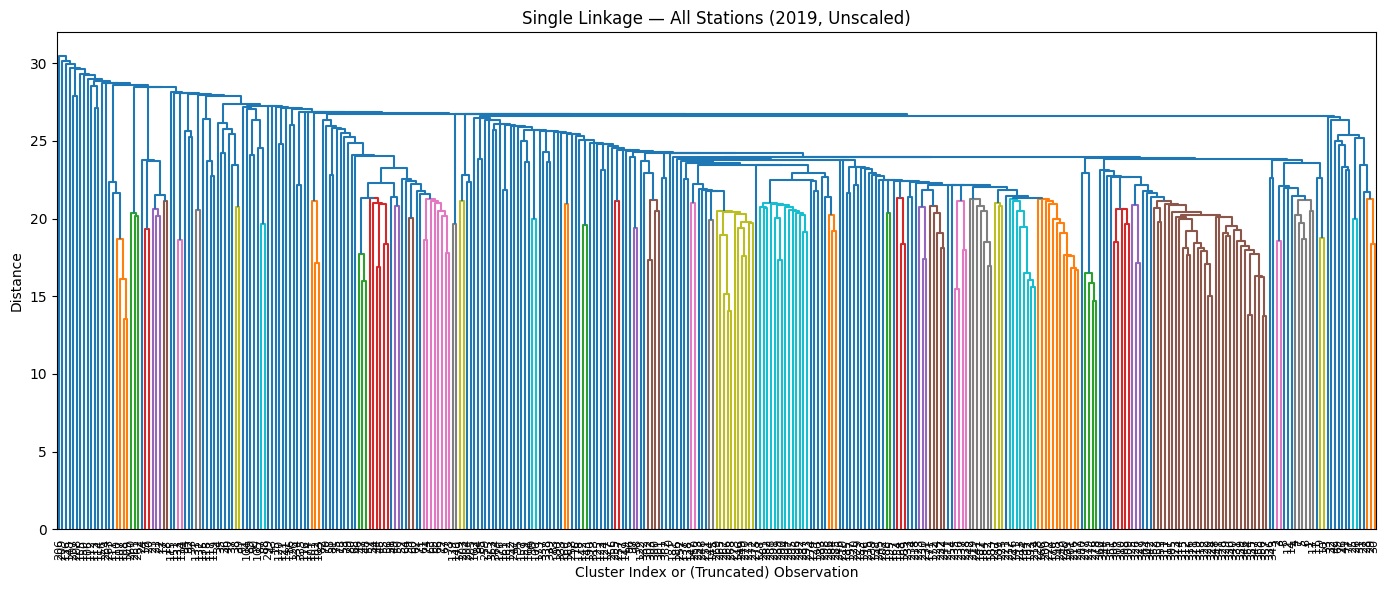

In [14]:
# ✅ Step 1: Compute the linkage matrix
linkage_matrix_all_single = linkage(stations_numeric, method='single')

# ✅ Step 2: Plot the dendrogram
plt.figure(figsize=(14, 6))

dendrogram(
    linkage_matrix_all_single,
    leaf_rotation=90.,
    leaf_font_size=8,
    show_contracted=False
)


plt.title('Single Linkage — All Stations (2019, Unscaled)')
plt.xlabel('Cluster Index or (Truncated) Observation')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### 🪢 Comparison: Dendrogram Analysis — OSLO, 2019 (Unscaled, Single Linkage)

* The **large purple cluster** in this dendrogram suggests that many days in Oslo's 2019 weather data shared **very similar characteristics**.

  * These points merged at relatively **low distances** (mostly between **4 and 6**), indicating a tight cluster of days with similar weather patterns.

* The **pink group** on the right represents the **second-largest cluster**.

  * Merges within this group occur at **higher distances**, implying **greater internal variability**.
  * While these days still cluster together, they’re more **diverse** in weather features compared to the denser purple group.

* This contrast between the two groups reveals a key insight:

  * **Purple cluster** = tighter, more homogeneous conditions.
  * **Pink cluster** = looser, more heterogeneous conditions.

#### ✂️ Cluster-Cutting Takeaways:

* Cutting the dendrogram **lower** would split the pink group into **smaller, tighter subclusters**.
* Cutting it **higher** would keep it together as a **larger, looser group**.
* 👉 *This illustrates a core principle of hierarchical clustering: the height of the cut directly influences both the number and cohesiveness of the resulting clusters.*

---
(AZ + ChatGPT)


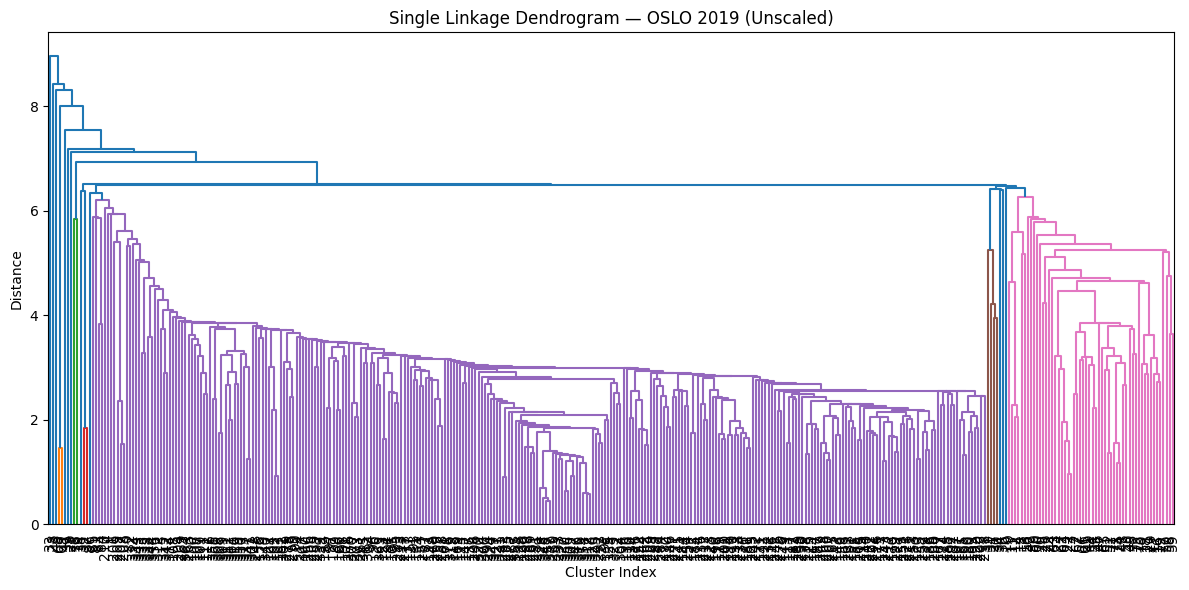

In [22]:
# --- 1. Filter columns: keep DATE, MONTH, and all OSLO_ columns ---
cols_to_keep = ['DATE', 'MONTH'] + [col for col in stations_2019_df.columns if col.startswith('OSLO_')]
oslo_2019_df = stations_2019_df[cols_to_keep].copy()

# --- 2. Drop DATE and MONTH before scaling ---
oslo_2019_numeric = oslo_2019_df.drop(columns=['DATE', 'MONTH'])

### FOR LATER COMPARATIVE WORK
# --- 3. Scale ---
scaler = StandardScaler()
oslo_2019_scaled_values = scaler.fit_transform(oslo_2019_numeric)
oslo_2019_scaled_df = pd.DataFrame(oslo_2019_scaled_values, columns=oslo_2019_numeric.columns)

# Optional: add DATE and MONTH back for reference (if needed)
oslo_2019_scaled_with_date = pd.concat([oslo_2019_df[['DATE', 'MONTH']].reset_index(drop=True), oslo_2019_scaled_df], axis=1)

### FOR SINGLE LINKAGE
# --- 4. Run single linkage on UNSCALED Oslo 2019 data ---
linkage_matrix_oslo_single = linkage(oslo_2019_numeric, method='single')

# --- 5. Plot dendrogram ---
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix_oslo_single,
    p=20,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=False
)
plt.title('Single Linkage Dendrogram — OSLO 2019 (Unscaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


 # b) 🧱 Dendogram Analysis: Complete Linkage, Scaled (All Stations, 2019)

This dendrogram shows hierarchical clustering using **Complete Linkage**, which you can think of as the "cautious commitment" strategy of clustering.

Unlike single linkage, where clusters merge if *any* two points are close enough, complete linkage requires *all* points in one cluster to be close to *all* points in the other cluster before they can join forces.

In other words:

> The distance between two clusters is defined as the **maximum distance between any pair of points**, one from each cluster.

So, if even one point in the new data group is too far from any point in the existing cluster, the merge won’t happen.

This cautious approach tends to create **tight, compact clusters** where every member is relatively close to all others — like a group of friends who all get along well, rather than just a few acquaintances.

---
* **Distinct Outlier Cluster (Blue):** The high merge point of the blue branch indicates a cluster of weather stations (and their particular days in 2019) that are **most distinct** from the rest of the dataset. This suggests these stations exhibit unique patterns or extreme values compared to others.
* **Two Major Groups (Orange and Green):** The remaining stations and their corresponding days in 2019 largely fall into two main groups, colored orange and green. These two larger clusters merge at a distance of around 32-33, showing they are more similar to each other than either is to the highly distinct blue cluster.


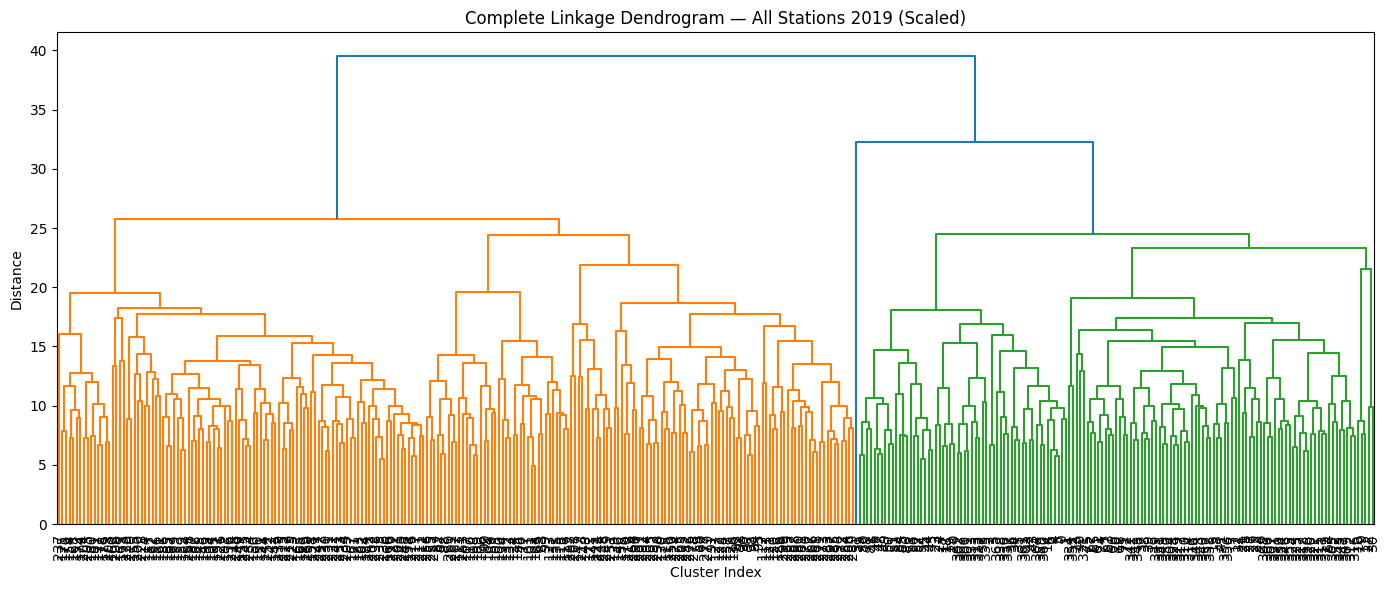

In [21]:
# --- 1. Compute linkage matrix using 'complete' method ---
linkage_matrix_complete = linkage(scaled_all_df, method='complete')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix_complete,
    truncate_mode='none',  # Only show the last merges (set to 'none' if you want the full tree)
    p=30,                   # Try 20, 30, 50 based on how detailed you want it
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Complete Linkage Dendrogram — All Stations 2019 (Scaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### 🧱 Comparison: Dendogram Analysis -- OSLO, 2019 (Scaled, Complete Linkage)

#### 🔍 Interpretation of the Narrow Green Cluster:

* **It’s a small, tight-knit cluster**:

  * Since complete linkage only merges when *all* points are relatively close, the fact that these green points clustered together means they’re **very similar to each other** across all features.

* **It’s *between* two larger clusters in terms of distance**:

  * Their merge height is *lower* than that of the larger clusters merging, meaning the green cluster is **closer (more similar)** to each of the big clusters than the big clusters are to each other.
  * But—because of complete linkage’s strict merging rule—it couldn’t join either big cluster early on, since it was **too far from at least one point** in each.

* **Possibility**: It might represent a **transitional weather pattern or an intermediate station**:

  * In a weather context, these data points may reflect a station or set of days that share characteristics with both bigger groups, but are still distinct enough to hold together on their own until a higher distance threshold.

---

### 🎭 Analogy (from ChatGPT):

> Imagine two large social circles (the orange and blue clusters). You, a green dot, have a few very close friends who also don’t quite fit into either big circle. You all vibe well with each other, but when trying to join the orange or blue parties, there’s always someone you're just too different from. So your little green group sticks together — tight, loyal, and a little in-betweeny — until someone finally ropes everyone into one big, awkward group hug much later.

---


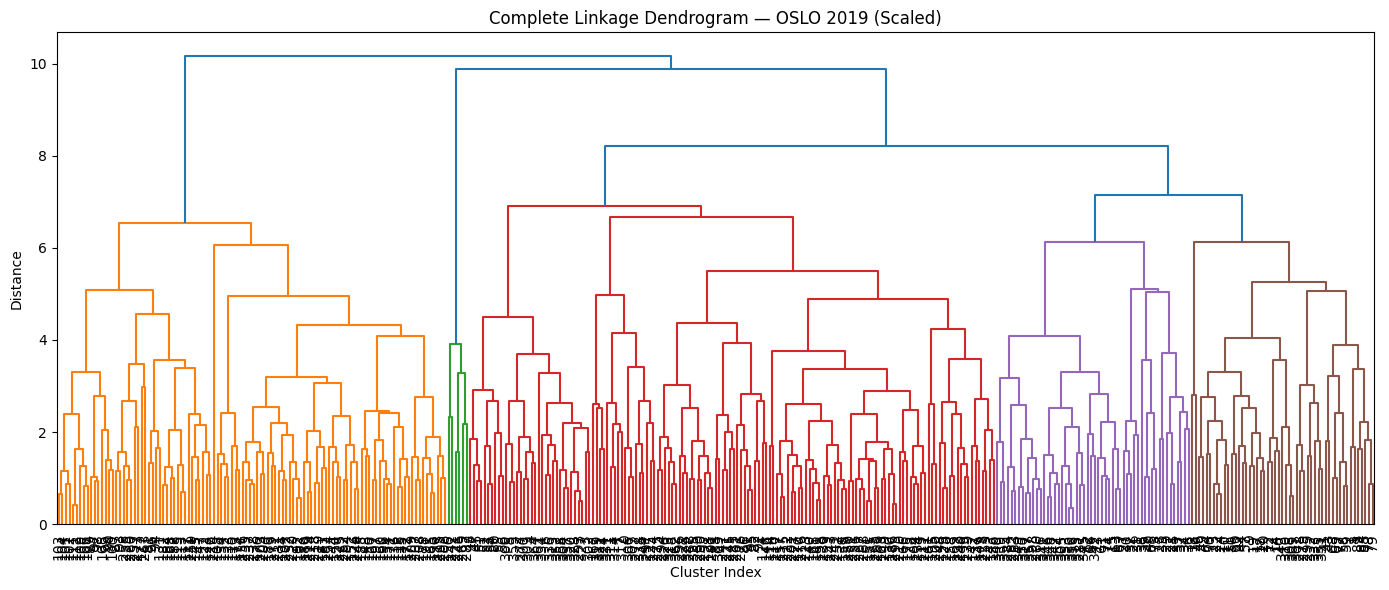

In [23]:
# --- 1. Compute linkage matrix using 'complete' method ---
oslo_linkage_matrix_complete = linkage(oslo_2019_scaled_df, method='complete')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    oslo_linkage_matrix_complete,
    truncate_mode='none',  # Only show the last merges (set to 'none' if you want the full tree)
    p=30,                   # Try 20, 30, 50 based on how detailed you want it
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Complete Linkage Dendrogram — OSLO 2019 (Scaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


# c) ⚖️ Dendogram Analysis: Average Linkage, Scaled (All Stations, 2019)

- Merge at 18 (Orange + Green):

  * At this point, the algorithm decides that, **on average**, the two groups aren’t *too* far apart to be one.
  * This is not about the worst-case scenario (like complete), or best-case (like single)—just the balance.
  * This merge reflects **statistical diplomacy**: there are enough moderate overlaps to justify fusing the groups.

- Final Merge at 31 (Blue Dot Left):

  * That last lonely dot or mini-cluster offscreen must have been **very different**—its average distance from the other clusters was large.
  * It only merges when there’s **nowhere else left to go** in the hierarchy.


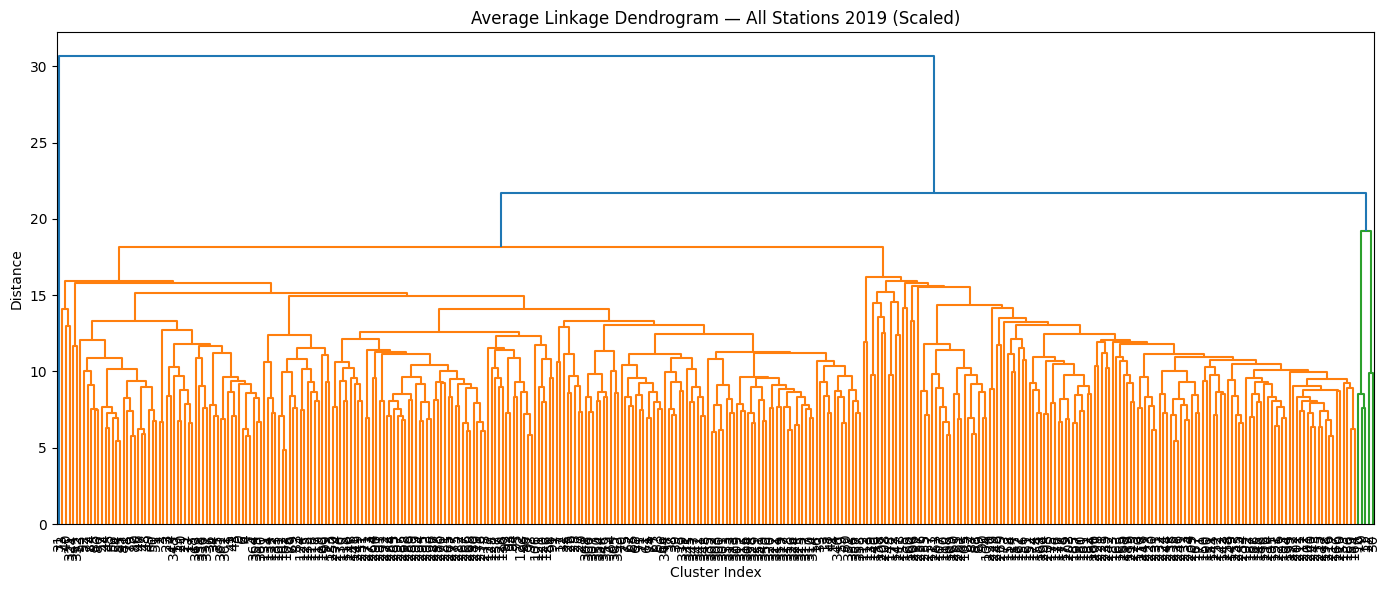

In [24]:
# --- 1. Compute linkage matrix using 'average' method ---
linkage_matrix_average = linkage(scaled_all_df, method='average')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix_average,
    truncate_mode='none',   # 'none' shows the full tree
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Average Linkage Dendrogram — All Stations 2019 (Scaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### ⚖️ Comparison: Dendogram Analysis -- OSLO, 2019 (Scaled, Average Linkage)

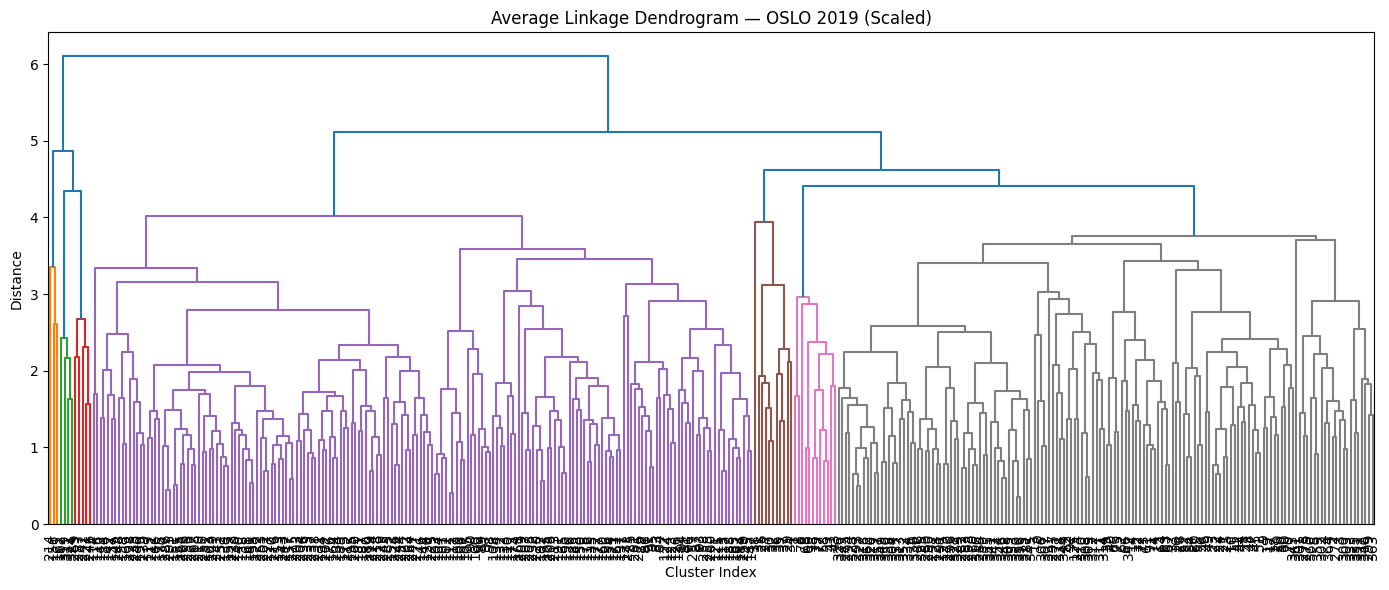

In [26]:
# --- 1. Compute linkage matrix using 'average' method ---
oslo_linkage_matrix_average = linkage(oslo_2019_scaled_df, method='average')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    oslo_linkage_matrix_average,
    truncate_mode='none',  # Only show the last merges (set to 'none' if you want the full tree)
    p=30,                   # Try 20, 30, 50 based on how detailed you want it
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Average Linkage Dendrogram — OSLO 2019 (Scaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


# d) 💭 Dendogram Analysis: Ward, Scaled (All Stations, 2019)

### Ward Linkage — OSLO vs All Stations

Ward linkage produces strikingly similar (almost isomorphic) dendrograms for all weather stations in 2019 and for just OSLO alone. This method clusters data by minimizing the **total within-cluster variance** — not just based on pairwise distances, but on how much "compactness" is gained or lost with each potential merge.

At each step, Ward’s algorithm considers all possible cluster pairs and chooses the one whose merger results in the **smallest increase in total within-cluster variance**. This makes it fundamentally different from methods like single or complete linkage, which rely on specific pairwise distances between clusters.

The similarity between the OSLO and all-station dendrograms suggests that OSLO's weather patterns may represent a kind of **microcosm** or **structural backbone** for the overall dataset. In other words, the way OSLO's daily weather clusters under Ward's criterion reflects — at least in shape — the broader clustering tendencies across all stations in 2019.


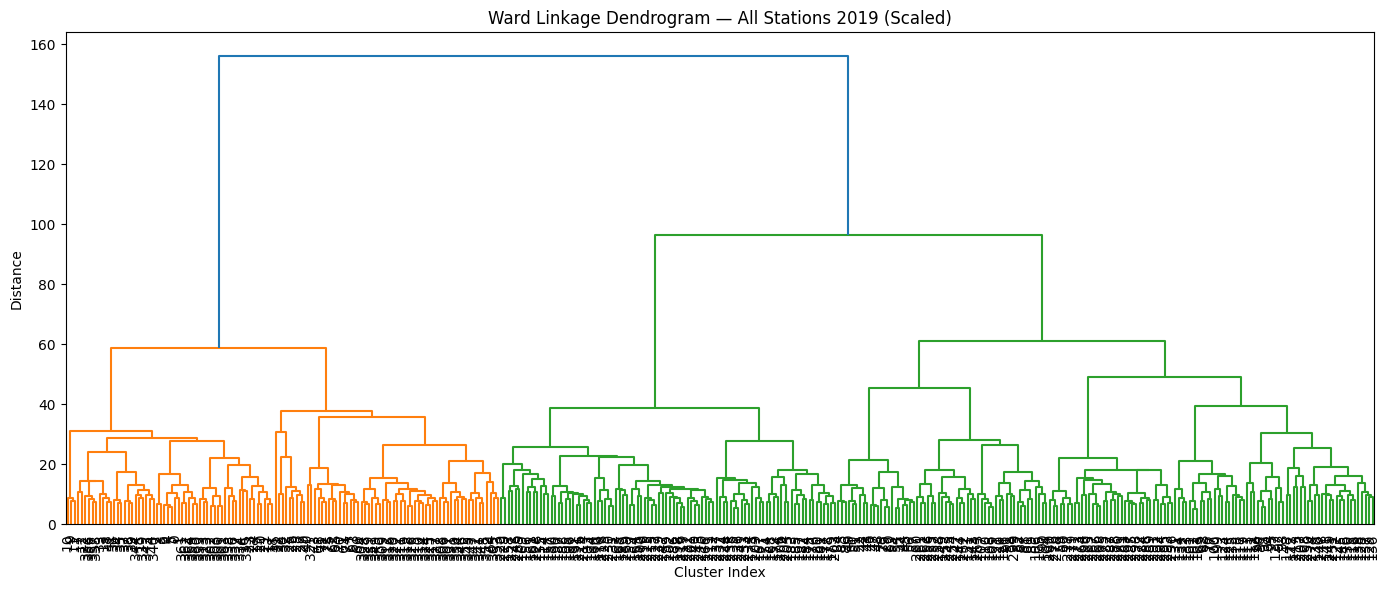

In [31]:
# --- 1. Compute linkage matrix using 'ward' method ---
linkage_matrix_ward = linkage(scaled_all_df, method='ward')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix_ward,
    truncate_mode='none',   # 'none' shows the full tree
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Ward Linkage Dendrogram — All Stations 2019 (Scaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### 💭 Comparison: Dendogram Analysis -- OSLO, 2019 (Scaled, Ward Linkage)

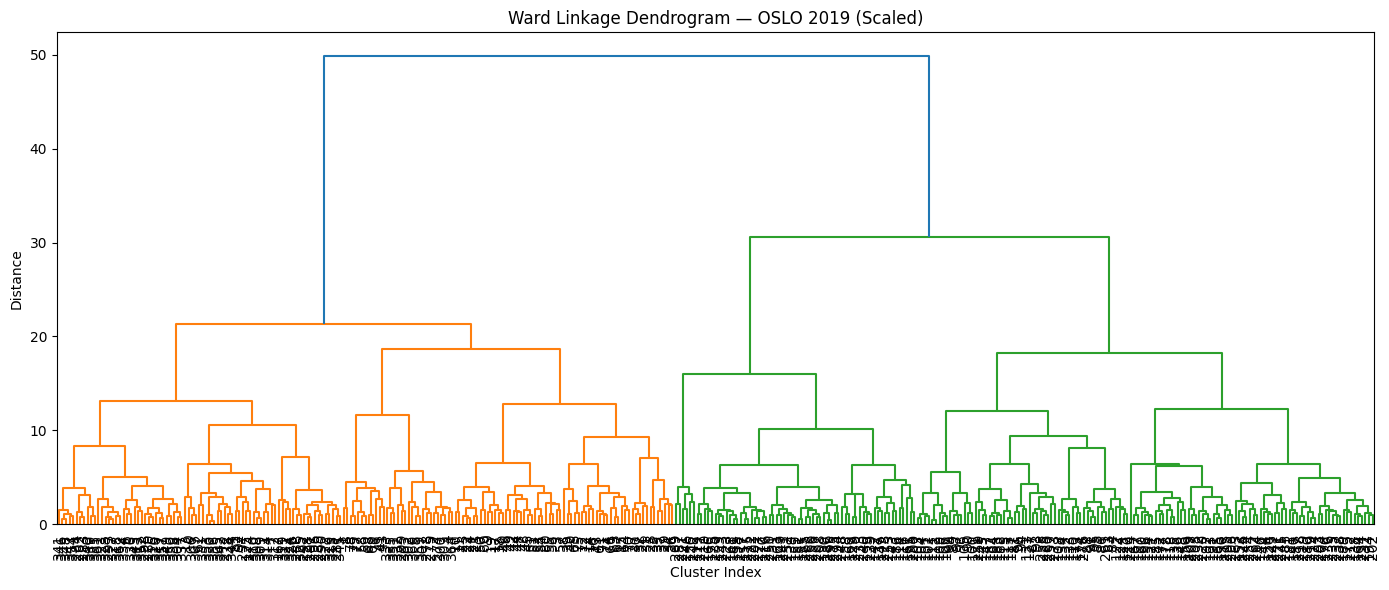

In [30]:
# --- 1. Compute linkage matrix using 'ward' method ---
oslo_linkage_matrix_ward = linkage(oslo_2019_scaled_df, method='ward')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    oslo_linkage_matrix_ward,
    truncate_mode='none',   # 'none' shows the full tree
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title('Ward Linkage Dendrogram — OSLO 2019 (Scaled)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


# QUESTION 3 - PCA

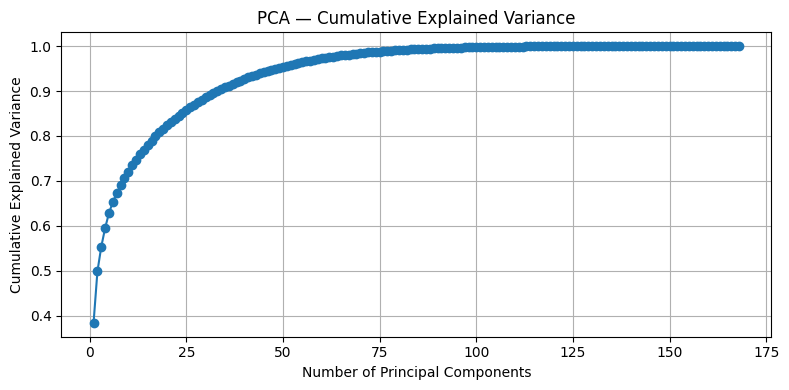

In [32]:
from sklearn.decomposition import PCA

# --- 1. Instantiate PCA ---
# Try reducing to number of stations, variables, or use explained variance
pca = PCA(n_components=None)  # Start with all to inspect variance explained
pca.fit(scaled_all_df)

# --- 2. Examine explained variance ---
explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

# --- 3. Plot cumulative variance ---
# import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()


### 🧭 Rethinking PCA on Wide vs. Long Format

Our initial cumulative PCA on the wide-format dataset showed that **95% of the variance** was only captured after including **50 principal components**. This unexpectedly high number is likely due to redundancy introduced by the dataset's structure:
each weather station's metrics occupy their own columns (e.g., `OSLO_temp_max`, `BERGEN_temp_max`), even though they represent the **same types of measurements** across different locations.

This format leads to:

* 🔁 **Highly correlated features**, especially across stations (e.g., temperature metrics),
* 📈 **Artificially inflated dimensionality**, and
* 🪞 Principal components that capture **repetitive, station-specific variance** rather than global weather patterns.

### 🎯 Decision: Reduce to 9 Components

To better reflect the *underlying structure* of the data, we decided to reduce the dataset to **9 principal components** — a number informed by:

* The fact that there are **11 core weather metrics**, many of which are tightly correlated (e.g., `temp_max`, `temp_mean`, `temp_min`);
* The intuition that a smaller number of latent factors likely drives the overall variation in daily weather patterns;
* A desire to retain interpretability while significantly reducing redundancy.

This reduced representation will be used to re-run hierarchical clustering and assess whether dimensionality reduction improves clarity and separation in the dendrogram.

In [40]:
# --- 4. Fit PCA with chosen number of components ---
pca = PCA(n_components=9)
reduced_df = pca.fit_transform(scaled_all_df)

# Optionally: convert to DataFrame
reduced_df = pd.DataFrame(reduced_df, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9'])


In [41]:
reduced_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-7.877110,2.823421,-1.042417,4.015804,0.428317,-0.889715,-1.224173,-0.735285,0.270098
1,-8.496269,5.384156,1.508944,3.386135,1.267630,-0.272062,-1.649925,0.059405,0.864047
2,-10.190505,7.125904,0.854599,3.936767,0.813699,3.210992,0.790849,0.929748,2.752122
3,-11.097790,6.040884,0.491590,5.364309,0.464907,0.709307,1.087348,0.438508,1.992351
4,-10.044650,3.675074,1.229049,6.202445,0.100108,-0.152300,-2.201164,0.906201,0.274569


In [42]:
# Export to CSV
reduced_df.to_csv('reduced_weather_2019.csv', index=False)


# PCA (All Stations, 2019) - Dendograms

### 🪢 Single Linkage

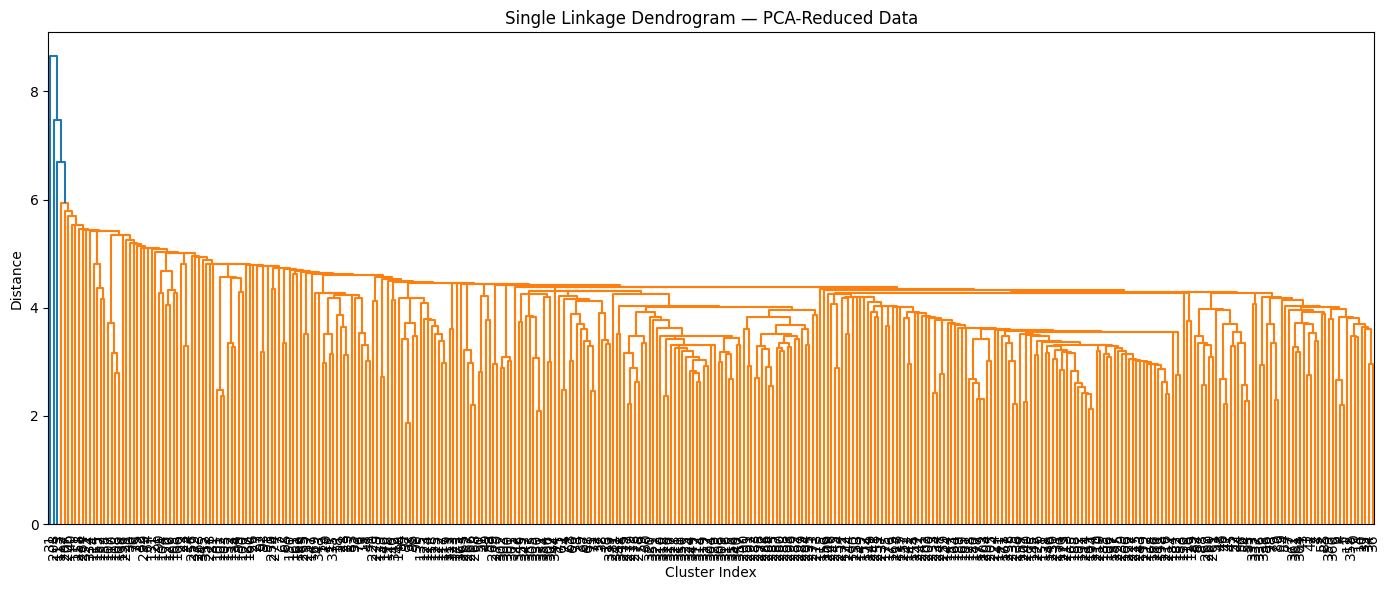

In [43]:
# --- 1. Compute linkage matrix ---
single_linkage_matrix_reduced = linkage(reduced_df, method='single')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    single_linkage_matrix_reduced,
    truncate_mode='none',
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Single Linkage Dendrogram — PCA-Reduced Data')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### 🧱 Complete Linkage

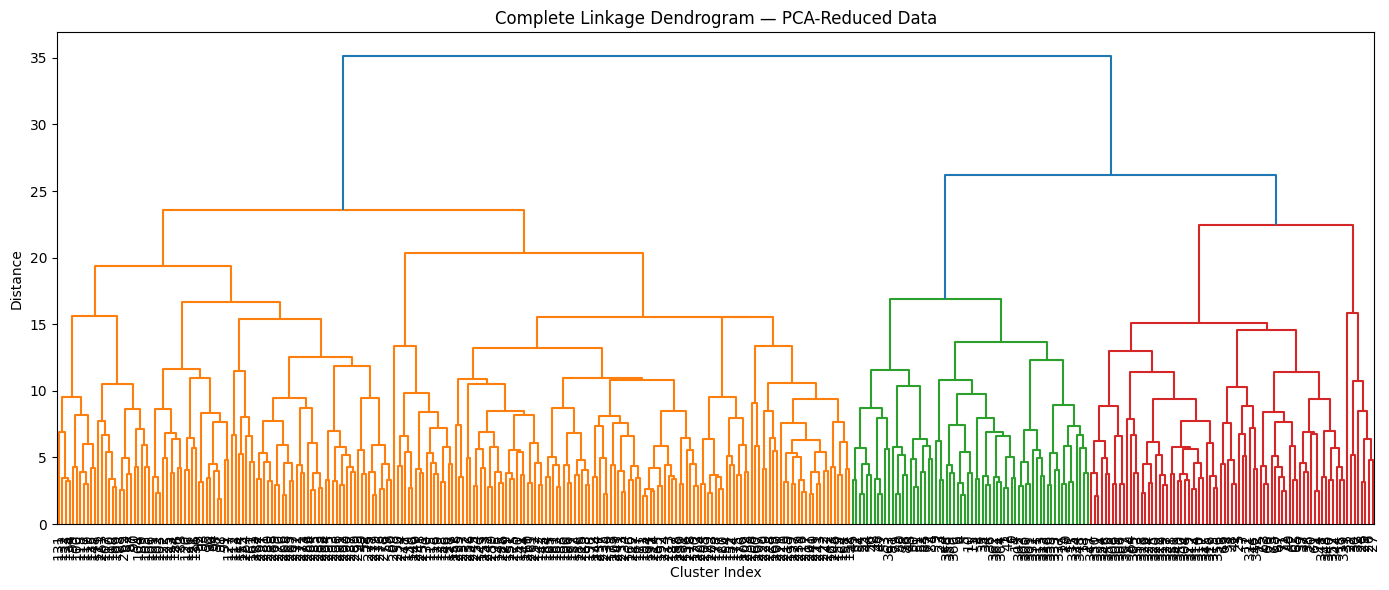

In [44]:
# --- 1. Compute linkage matrix ---
complete_linkage_matrix_reduced = linkage(reduced_df, method='complete')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    complete_linkage_matrix_reduced,
    truncate_mode='none',
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Complete Linkage Dendrogram — PCA-Reduced Data')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### ⚖️ Average Linkage

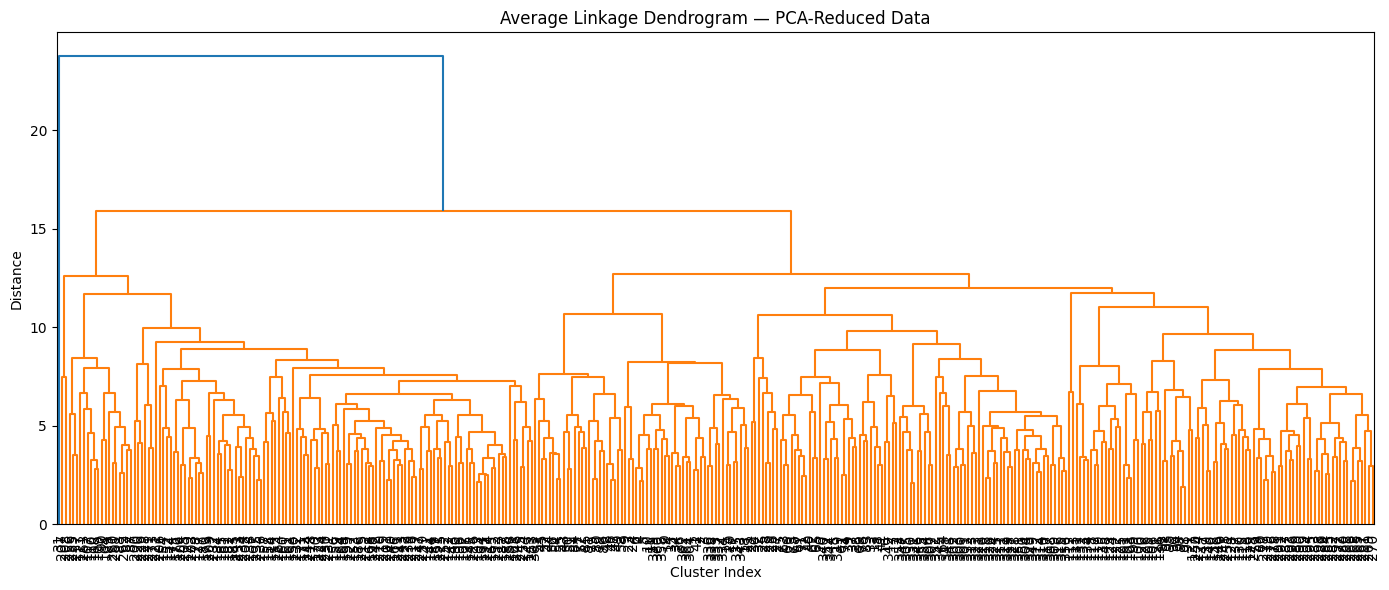

In [45]:
# --- 1. Compute linkage matrix ---
average_linkage_matrix_reduced = linkage(reduced_df, method='average')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    average_linkage_matrix_reduced,
    truncate_mode='none',
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Average Linkage Dendrogram — PCA-Reduced Data')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


### 💭 Ward Linkage

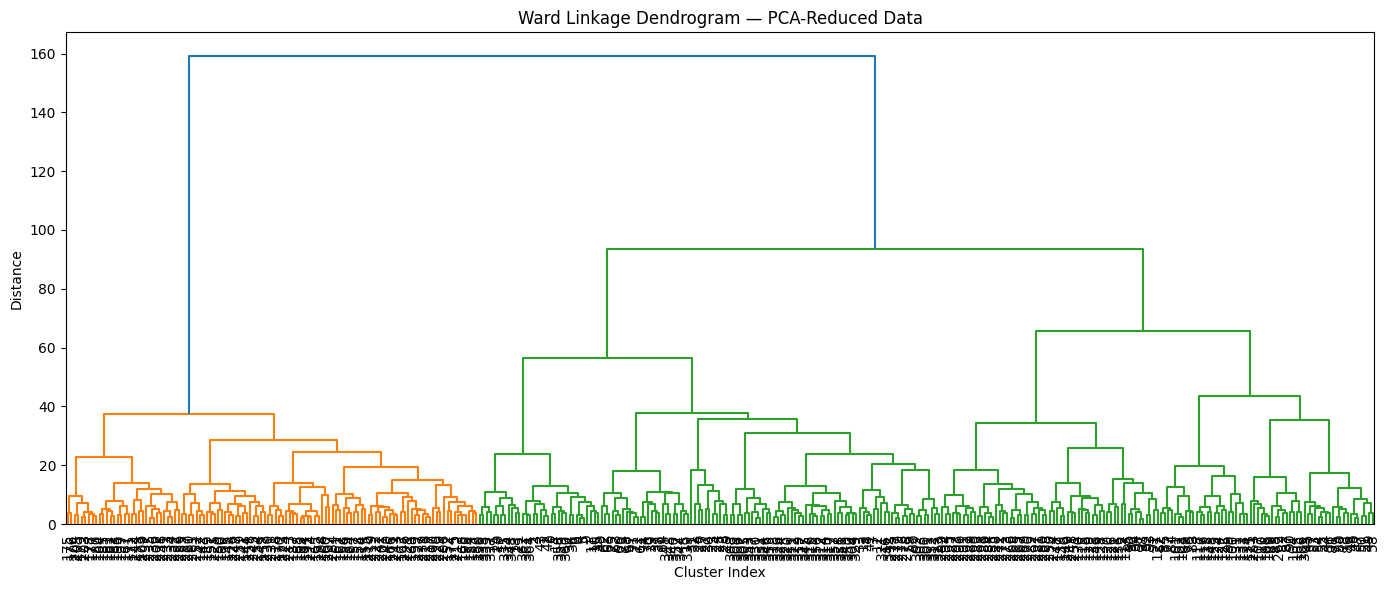

In [46]:
# --- 1. Compute linkage matrix ---
ward_linkage_matrix_reduced = linkage(reduced_df, method='ward')

# --- 2. Plot the dendrogram ---
plt.figure(figsize=(14, 6))
dendrogram(
    ward_linkage_matrix_reduced,
    truncate_mode='none',
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Ward Linkage Dendrogram — PCA-Reduced Data')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


# Compare with 'Pleasant Weather' Labels

In [47]:
reduced_df.shape

(365, 9)

In [48]:
# Import 'pleasant_weather'
pleasant_weather = pd.read_csv('pleasant_weather_Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv')

In [49]:
pleasant_weather.columns

Index(['DATE', 'BASEL_pleasant_weather', 'BELGRADE_pleasant_weather',
       'BUDAPEST_pleasant_weather', 'DEBILT_pleasant_weather',
       'DUSSELDORF_pleasant_weather', 'HEATHROW_pleasant_weather',
       'KASSEL_pleasant_weather', 'LJUBLJANA_pleasant_weather',
       'MAASTRICHT_pleasant_weather', 'MADRID_pleasant_weather',
       'MUNCHENB_pleasant_weather', 'OSLO_pleasant_weather',
       'SONNBLICK_pleasant_weather', 'STOCKHOLM_pleasant_weather',
       'VALENTIA_pleasant_weather'],
      dtype='object')

In [50]:
# Convert 'DATE' from yyyymmdd (int or str) to datetime
pleasant_weather['DATE'] = pd.to_datetime(pleasant_weather['DATE'].astype(str), format='%Y%m%d')

# Now filter for 2019
pleasant_2019 = pleasant_weather[pleasant_weather['DATE'].dt.year == 2019].copy()


In [51]:
pleasant_2019.shape

(365, 16)

In [52]:
# Make sure DATE columns have the same dtype and format
pleasant_2019['DATE'] = pd.to_datetime(pleasant_2019['DATE'])
scaled_all_with_date['DATE'] = pd.to_datetime(scaled_all_with_date['DATE'])

# Merge on DATE
merged_df = pd.merge(scaled_all_with_date, pleasant_2019, on='DATE', how='left')


In [54]:
list(merged_df.columns)

['DATE',
 'MONTH',
 'BASEL_cloud_cover',
 'BASEL_wind_speed',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_snow_depth',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',
 'DEBILT_cloud_cover',
 'DEBILT_wind_speed',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_wind_speed',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 

## ✅ Function: Perform clustering and plot summaries

In [70]:
def run_hierarchical_clustering(method_name, pca_data, merged_df, pleasant_cols, n_clusters=5):
    # Generate linkage matrix
    linkage_matrix = linkage(pca_data, method=method_name)

    # Assign cluster labels
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    cluster_col_name = f'{method_name} cluster'

    # Add to DataFrame
    merged_df[cluster_col_name] = cluster_labels

    # Group and summarize
    cluster_summary = merged_df.groupby(cluster_col_name)[pleasant_cols].mean()

    # Plot heatmap
    plt.figure(figsize=(14, 6))
    sns.heatmap(cluster_summary, cmap='YlGnBu', annot=True, fmt=".2f", cbar_kws={'label': 'Proportion Pleasant'})
    plt.title(f"Proportion of Pleasant Weather Days per Cluster ({method_name.title()} Linkage)", fontsize=14)
    plt.ylabel(f"{method_name.title()} Linkage Cluster")
    plt.xlabel("Weatherstation")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return cluster_summary


## 🌀 Run all methods


🔹 Running clustering for: SINGLE


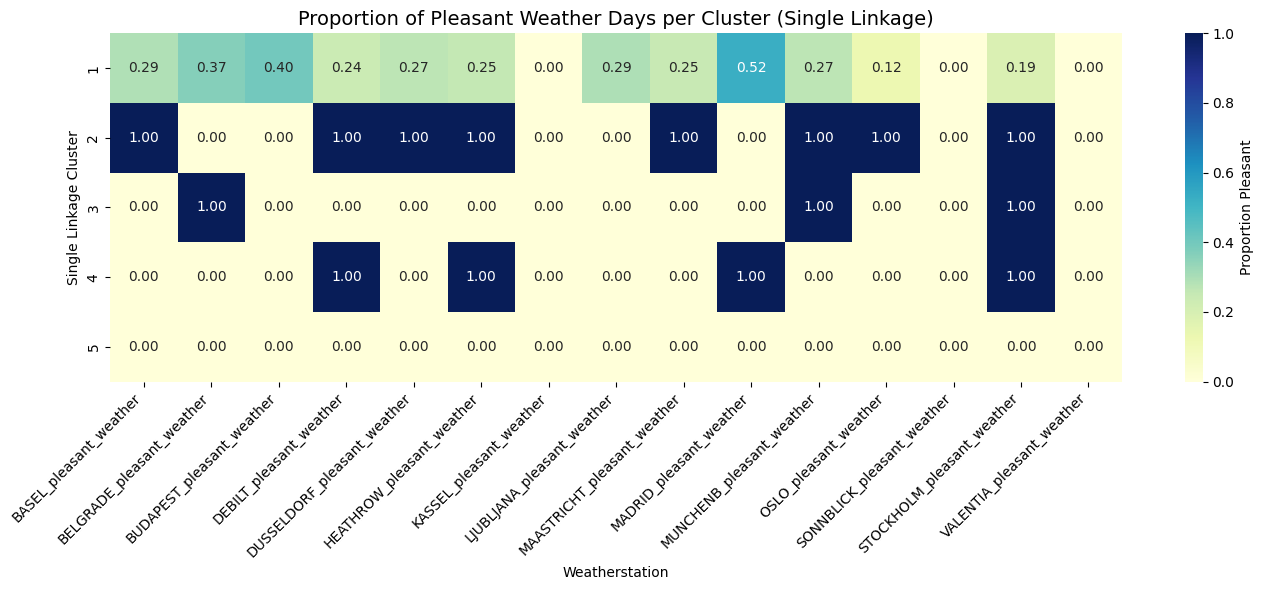


🔹 Running clustering for: COMPLETE


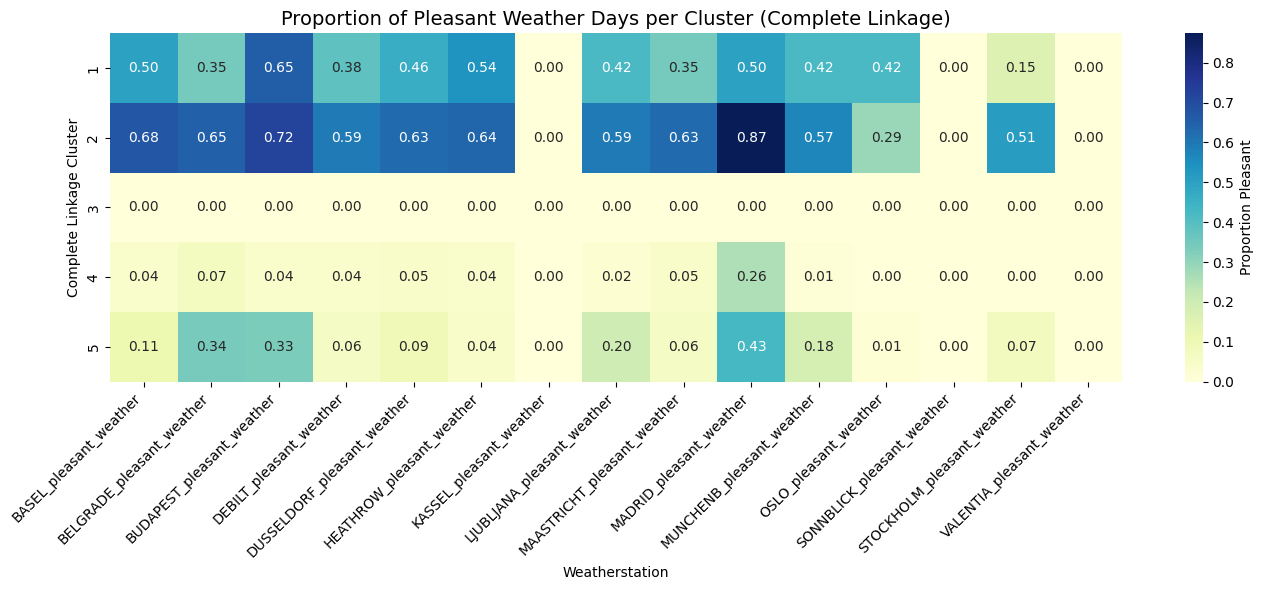


🔹 Running clustering for: AVERAGE


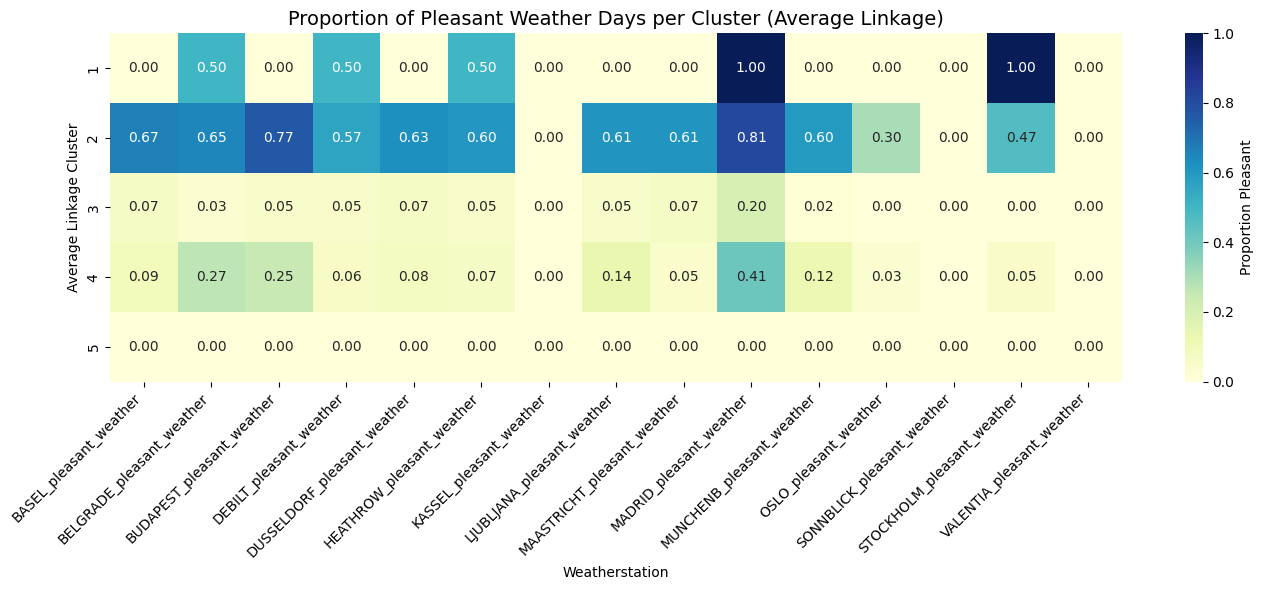


🔹 Running clustering for: WARD


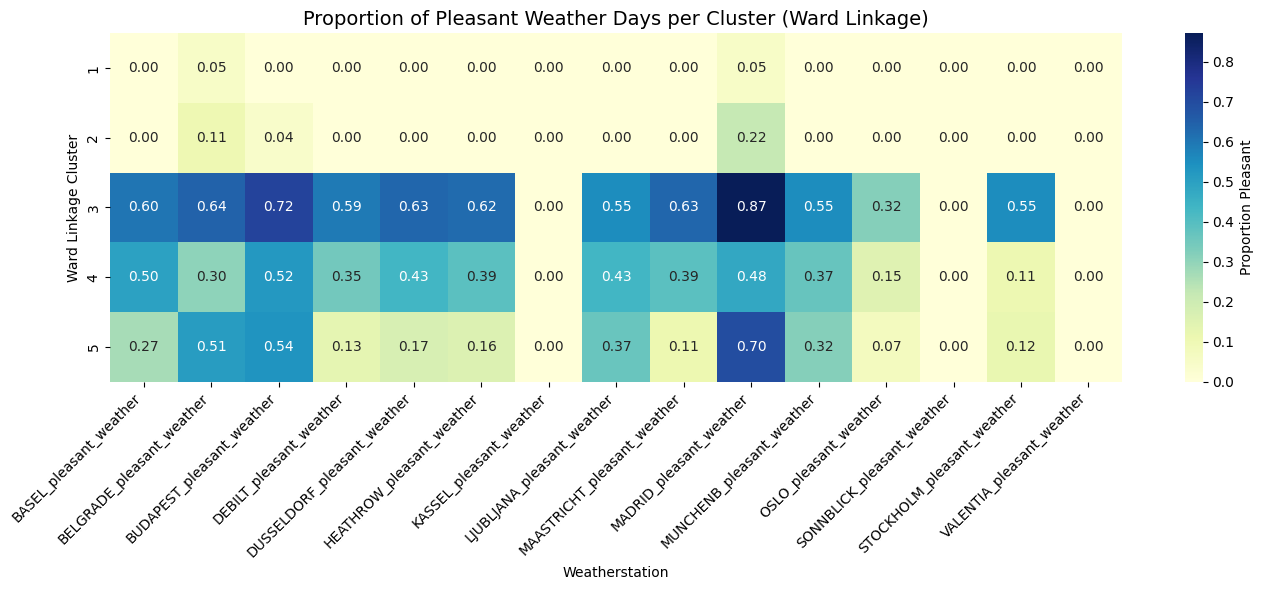

In [71]:
# Exclude certain columns
exclude_cols = ['DATE', 'MONTH'] + [col for col in merged_df.columns if '_pleasant_weather' in col]
features_for_pca = merged_df.drop(columns=exclude_cols)

# Run PCA
pca = PCA(n_components=9)
pca_data = pca.fit_transform(features_for_pca)

# Identify pleasant weather columns
pleasant_cols = [col for col in merged_df.columns if '_pleasant_weather' in col]

# Loop through linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']
cluster_summaries = {}

for method in linkage_methods:
    print(f"\n🔹 Running clustering for: {method.upper()}")
    summary = run_hierarchical_clustering(method, pca_data, merged_df, pleasant_cols)
    cluster_summaries[method] = summary


---
---
---
---
# Further Study Notes
---
---
---
---

## 🪢 Single Linkage Summary
---

**✅ Checklist**:

* **excluded non-numeric and interpretive columns** from PCA (perfect).
* **ran PCA on actual weather data**, smartly reduced to 9 components.
* ran **hierarchical clustering** (`single` linkage in this case).
* joined **cluster labels** back into the dataframe.
* **interpreted clusters** by checking average pleasant-weather rates per cluster.

---

### 🔍 How to Read the `single_cluster_summary`:

Each value is the **mean of a boolean column** — i.e., the **proportion of days marked “pleasant”** for that weatherstation **within that cluster**.

So:

* A value of **1.0** means *every day* in that cluster was labeled “pleasant” at that weatherstation.
* A value of **0.0** means *none* were.
* A value like **0.29** means \~29% of the days were “pleasant” in that cluster.

---


In [55]:
# Columns to exclude from PCA/clustering
exclude_cols = ['DATE', 'MONTH'] + [col for col in merged_df.columns if '_pleasant_weather' in col]

# Select features for PCA/clustering
features_for_pca = merged_df.drop(columns=exclude_cols)

# Run PCA on these features
# from sklearn.decomposition import PCA

pca = PCA(n_components=9)
pca_data = pca.fit_transform(features_for_pca)

# Then run hierarchical clustering on pca_data
from scipy.cluster.hierarchy import linkage, fcluster

single_linkage_matrix = linkage(pca_data, method='single')
single_cluster_labels = fcluster(single_linkage_matrix, 5, criterion='maxclust')

# Add cluster labels back to merged_df
merged_df['single cluster'] = single_cluster_labels

# Now analyze clusters vs pleasant weather columns
pleasant_cols = [col for col in merged_df.columns if '_pleasant_weather' in col]
single_cluster_summary = merged_df.groupby('single cluster')[pleasant_cols].mean()
print(single_cluster_summary)


                BASEL_pleasant_weather  BELGRADE_pleasant_weather  \
single cluster                                                      
1                             0.290859                   0.365651   
2                             1.000000                   0.000000   
3                             0.000000                   1.000000   
4                             0.000000                   0.000000   
5                             0.000000                   0.000000   

                BUDAPEST_pleasant_weather  DEBILT_pleasant_weather  \
single cluster                                                       
1                                0.401662                 0.235457   
2                                0.000000                 1.000000   
3                                0.000000                 0.000000   
4                                0.000000                 1.000000   
5                                0.000000                 0.000000   

                DUSSELDOR

### 🔍 PCA Component (Loadings) Inspection for Interpretability:

PCA transforms your data into **new axes (components)** that are *linear combinations* of the original variables. These new components are unlabelled, abstract directions of maximum variance. So when you cluster on PCA-reduced data:

> You’re clustering based on **compressed relationships**, not directly on the original features.

This means:

* You **can** find structure.
* But that structure is based on **latent blends** of temperature, pressure, sunshine, etc.
* So it’s not inherently interpretable—*unless you dig into the components*.

---

### What You Can Do To Interpret This:

1. **Check the PCA components (loadings):**
   * Each row is a principal component.
   * Each column is an original feature.
   * Values = contribution of each feature to that component.
   * High-magnitude values = features that drive that component.

2. **Name your components (roughly):**
   For example:

   * If PC1 is dominated by `temp_mean`, `temp_max`, and `sunshine`, you might call it "Warm & Sunny".
   * If PC2 is driven by `humidity`, `cloud_cover`, and `precipitation`, maybe it’s “Wet & Overcast”.

3. **Then interpret clusters *through* those lenses**:
   You’d say something like:

   > “Cluster 3 is characterized by high scores on Component 1 (‘Warm & Sunny’) and low on Component 2 (‘Wet & Overcast’), and aligns with high pleasant-weather counts for Madrid and Ljubljana.”

---

### ⚠️ TL;DR

> Clustering on PCA data without understanding the components gives you structure, but not meaning.

- It created 9 new axes (directions) in a high-dimensional space that:
  - Are linear combinations of your 168 original variables
  - Explain descending amounts of variance (PC1 explains the most, PC2 the next most, etc.)
  - So you're not down to 9 observations—you're in a transformed space with 9 dimensions.




In [59]:
pca_components_df = pd.DataFrame(
    pca.components_,
    columns=features_for_pca.columns,
    index=[f'PC{i+1}' for i in range(9)]
)
print(pca_components_df)

     BASEL_cloud_cover  BASEL_wind_speed  BASEL_humidity  BASEL_pressure  \
PC1          -0.049724         -0.051282       -0.065832        0.001259   
PC2          -0.118693         -0.083450       -0.080336        0.202148   
PC3           0.134319         -0.037553        0.086418       -0.053657   
PC4           0.063094         -0.072299        0.124067        0.205438   
PC5          -0.011475          0.244686       -0.215939        0.012770   
PC6           0.014731         -0.151081       -0.030166       -0.089149   
PC7          -0.147063         -0.023300       -0.076707       -0.049687   
PC8           0.055808         -0.077735       -0.032544        0.027610   
PC9           0.111327          0.026838        0.062052        0.039427   

     BASEL_global_radiation  BASEL_precipitation  BASEL_snow_depth  \
PC1                0.069955             0.011740         -0.024385   
PC2                0.065934            -0.096682          0.007394   
PC3                0.006498  

In [60]:
component_df = pd.DataFrame(pca.components_, columns=features_for_pca.columns, index=[f'PC{i+1}' for i in range(9)])
component_df.T.sort_values('PC1', ascending=False).head(10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
MAASTRICHT_temp_max,0.130879,-0.006742,-0.040045,-0.020153,-0.024308,-0.019779,-0.004802,0.080902,-0.033241
DUSSELDORF_temp_max,0.130546,-0.009574,-0.039412,-0.019405,-0.026983,-0.018177,-0.005783,0.082081,-0.020464
BASEL_temp_max,0.129587,-0.021512,-0.070080,-0.019935,0.013849,0.000568,0.009046,-0.014642,-0.048531
BASEL_temp_mean,0.129222,-0.050659,-0.046944,0.007754,-0.002890,-0.022807,0.003401,-0.012957,-0.051798
MUNCHENB_temp_mean,0.128982,-0.060966,-0.043812,0.000350,-0.011602,0.009735,-0.022744,-0.021456,0.010997
DEBILT_temp_max,0.128949,-0.008696,-0.021128,-0.011512,-0.025255,-0.018589,-0.034588,0.083839,-0.035858
DUSSELDORF_temp_mean,0.128761,-0.044440,-0.052788,0.013414,-0.017868,-0.016336,-0.019274,0.071872,-0.033967
MAASTRICHT_temp_mean,0.128538,-0.039721,-0.055623,0.008513,-0.019200,-0.017668,-0.021425,0.078221,-0.054254
LJUBLJANA_temp_max,0.128186,-0.035683,-0.035897,0.026377,-0.023573,0.011181,-0.009460,-0.061763,0.082238
TOURS_temp_max,0.128070,-0.000433,-0.027913,0.000615,-0.011426,-0.034755,0.029795,-0.008170,-0.123358


In [61]:
component_df.T.sort_values('PC2', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
DUSSELDORF_pressure,0.021463,0.222148,0.010566,0.152306,-0.042104,-0.023063,-0.033596,0.015367,0.028162
DEBILT_pressure,0.024356,0.218355,0.046462,0.154271,-0.041460,-0.020785,-0.025540,-0.022916,0.034374
MAASTRICHT_pressure,0.020324,0.216888,0.023876,0.174022,-0.026622,-0.040635,-0.025268,-0.014470,0.036495
HEATHROW_pressure,0.019565,0.205199,0.065661,0.177026,0.006518,-0.037410,-0.015890,-0.080934,0.035891
BASEL_pressure,0.001259,0.202148,-0.053657,0.205438,0.012770,-0.089149,-0.049687,0.027610,0.039427
SONNBLICK_pressure,0.008792,0.198498,-0.134568,0.127411,-0.022447,-0.015014,-0.041334,0.085273,0.063951
LJUBLJANA_pressure,0.006446,0.189884,-0.156227,0.092056,-0.076621,-0.049164,-0.072420,0.081789,0.078714
TOURS_pressure,0.004824,0.182677,-0.002323,0.240835,0.078812,-0.100032,-0.031425,-0.042063,0.043917
BELGRADE_pressure,0.002176,0.159954,-0.180465,0.059504,-0.097099,-0.051193,-0.079968,0.059794,0.123204
OSLO_pressure,0.028037,0.141720,0.130183,0.015522,-0.136640,0.137456,-0.087131,0.155917,0.042106


In [62]:
component_df.T.sort_values('PC3', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
SONNBLICK_cloud_cover,-0.016658,-0.109379,0.226868,0.094366,0.047859,-0.067546,-0.029830,0.162468,0.098481
SONNBLICK_humidity,-0.003018,-0.089043,0.224384,0.073884,0.044577,0.007059,-0.038831,0.170981,0.076777
LJUBLJANA_cloud_cover,-0.045745,-0.099071,0.196237,0.000465,-0.028400,-0.079800,0.031034,0.144943,-0.101617
SONNBLICK_precipitation,-0.034619,-0.063339,0.163860,0.070519,0.110452,-0.148061,-0.002019,-0.095454,0.073443
LJUBLJANA_precipitation,-0.006544,-0.073784,0.160434,0.000918,0.020677,-0.077930,0.074092,-0.122577,-0.051550
MUNCHENB_cloud_cover,-0.053002,-0.095243,0.156170,0.134723,0.020142,-0.063387,-0.077562,0.114568,0.045786
LJUBLJANA_humidity,-0.045480,-0.107072,0.152093,-0.002230,-0.107110,-0.099379,0.070184,0.052042,-0.214605
BUDAPEST_precipitation,-0.002438,-0.059993,0.142462,-0.007687,0.017925,-0.038594,0.007812,-0.063588,-0.090710
BASEL_cloud_cover,-0.049724,-0.118693,0.134319,0.063094,-0.011475,0.014731,-0.147063,0.055808,0.111327
OSLO_sunshine,0.063544,0.064351,0.133712,-0.055679,0.089296,0.098710,-0.241240,-0.134496,-0.155431


In [63]:
component_df.T.sort_values('PC4', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
TOURS_pressure,0.004824,0.182677,-0.002323,0.240835,0.078812,-0.100032,-0.031425,-0.042063,0.043917
BASEL_pressure,0.001259,0.202148,-0.053657,0.205438,0.012770,-0.089149,-0.049687,0.027610,0.039427
MADRID_sunshine,0.069313,0.020597,0.044139,0.185085,0.208343,0.053311,0.166960,0.078817,-0.000298
MADRID_pressure,-0.052255,0.111090,-0.082625,0.178580,0.094322,-0.167754,-0.054357,-0.012622,-0.005939
HEATHROW_pressure,0.019565,0.205199,0.065661,0.177026,0.006518,-0.037410,-0.015890,-0.080934,0.035891
MUNCHENB_humidity,-0.061786,-0.046678,0.120903,0.176692,-0.166590,-0.138484,0.017684,0.011565,-0.086509
MAASTRICHT_pressure,0.020324,0.216888,0.023876,0.174022,-0.026622,-0.040635,-0.025268,-0.014470,0.036495
MAASTRICHT_humidity,-0.088908,-0.102288,0.005654,0.164809,-0.053731,0.079016,-0.015014,-0.188374,-0.014280
MAASTRICHT_cloud_cover,-0.050780,-0.133431,-0.072635,0.158056,0.068761,0.195411,-0.036048,0.031479,-0.014474
DEBILT_humidity,-0.081662,-0.074941,-0.069375,0.156767,-0.101184,0.091773,0.095601,-0.156155,-0.024781


In [64]:
component_df.T.sort_values('PC5', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
BASEL_wind_speed,-0.051282,-0.083450,-0.037553,-0.072299,0.244686,-0.151081,-0.023300,-0.077735,0.026838
DEBILT_wind_speed,-0.031620,-0.084109,-0.120700,-0.057869,0.218414,-0.164115,-0.126139,0.165212,0.026849
MADRID_sunshine,0.069313,0.020597,0.044139,0.185085,0.208343,0.053311,0.166960,0.078817,-0.000298
DUSSELDORF_wind_speed,-0.039676,-0.105197,-0.146523,-0.033192,0.206548,-0.211614,-0.092306,0.115620,0.034753
MAASTRICHT_wind_speed,-0.038232,-0.091307,-0.140743,-0.079748,0.201342,-0.196051,-0.117948,0.139886,0.026753
MADRID_global_radiation,0.101345,0.012622,0.065144,0.095595,0.192444,0.074371,0.091648,0.048549,0.034905
OSLO_snow_depth,-0.071854,0.054780,-0.066053,-0.010712,0.164062,-0.025846,0.160450,0.002270,0.076716
TOURS_wind_speed,-0.027159,-0.108494,-0.073908,-0.081805,0.156814,-0.127041,-0.078114,0.058704,-0.055872
MAASTRICHT_precipitation,-0.012815,-0.111528,-0.045491,0.039390,0.148199,-0.004083,-0.096045,-0.174728,0.098500
DEBILT_precipitation,-0.007832,-0.106581,-0.080133,0.025907,0.145418,-0.025519,-0.071161,-0.000576,0.033185


In [65]:
component_df.T.sort_values('PC6', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
DEBILT_cloud_cover,-0.043774,-0.111762,-0.097045,0.142465,0.059521,0.235132,-0.000789,0.068695,-0.048983
HEATHROW_cloud_cover,-0.030675,-0.099823,-0.067518,0.102340,-0.001105,0.228211,-0.034019,0.191008,-0.090640
MAASTRICHT_cloud_cover,-0.050780,-0.133431,-0.072635,0.158056,0.068761,0.195411,-0.036048,0.031479,-0.014474
DUSSELDORF_cloud_cover,-0.055569,-0.139405,-0.060328,0.152730,0.080485,0.179689,-0.062658,-0.015431,-0.019729
STOCKHOLM_pressure,0.034358,0.118841,0.108678,0.000989,-0.145409,0.147741,-0.072660,0.224246,0.091499
DUSSELDORF_snow_depth,-0.025199,-0.018809,0.038052,-0.087793,-0.002027,0.147380,0.294665,0.000549,0.057919
MUNCHENB_global_radiation,0.110610,0.041709,-0.063756,-0.091863,0.079382,0.142686,0.028714,-0.018196,-0.006168
STOCKHOLM_sunshine,0.082970,0.042082,0.094971,-0.017558,0.068678,0.139419,-0.160593,0.044393,0.040570
OSLO_pressure,0.028037,0.141720,0.130183,0.015522,-0.136640,0.137456,-0.087131,0.155917,0.042106
STOCKHOLM_global_radiation,0.107091,0.017284,0.102768,-0.018263,0.100759,0.136468,-0.090357,0.044131,0.047998


In [66]:
component_df.T.sort_values('PC7', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
DUSSELDORF_snow_depth,-0.025199,-0.018809,0.038052,-0.087793,-0.002027,0.147380,0.294665,0.000549,0.057919
GDANSK_snow_depth,-0.045968,0.003913,0.045658,-0.025384,0.056731,0.084685,0.260513,-0.023382,0.090923
OSLO_cloud_cover,-0.027197,-0.078673,-0.105545,0.038203,-0.061480,-0.059847,0.260445,0.197655,0.199871
HEATHROW_snow_depth,-0.012439,-0.021993,0.027478,-0.057647,-0.005401,0.086442,0.248613,-0.004197,0.116528
OSLO_humidity,-0.042798,-0.072223,-0.159108,0.078447,-0.166868,-0.129267,0.197513,0.096466,0.063478
STOCKHOLM_precipitation,-0.002698,-0.065666,-0.077750,-0.005801,0.021447,-0.088287,0.177029,-0.084580,0.014401
MADRID_sunshine,0.069313,0.020597,0.044139,0.185085,0.208343,0.053311,0.166960,0.078817,-0.000298
OSLO_snow_depth,-0.071854,0.054780,-0.066053,-0.010712,0.164062,-0.025846,0.160450,0.002270,0.076716
OSLO_precipitation,0.008959,-0.065180,-0.076029,0.038402,0.000683,-0.033412,0.141610,0.163058,0.175455
BASEL_sunshine,0.086351,0.100031,-0.108330,-0.069048,0.043920,0.053120,0.126909,-0.000138,-0.111432


In [67]:
component_df.T.sort_values('PC8', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
STOCKHOLM_pressure,0.034358,0.118841,0.108678,0.000989,-0.145409,0.147741,-0.072660,0.224246,0.091499
OSLO_cloud_cover,-0.027197,-0.078673,-0.105545,0.038203,-0.061480,-0.059847,0.260445,0.197655,0.199871
HEATHROW_cloud_cover,-0.030675,-0.099823,-0.067518,0.102340,-0.001105,0.228211,-0.034019,0.191008,-0.090640
SONNBLICK_humidity,-0.003018,-0.089043,0.224384,0.073884,0.044577,0.007059,-0.038831,0.170981,0.076777
DEBILT_wind_speed,-0.031620,-0.084109,-0.120700,-0.057869,0.218414,-0.164115,-0.126139,0.165212,0.026849
OSLO_precipitation,0.008959,-0.065180,-0.076029,0.038402,0.000683,-0.033412,0.141610,0.163058,0.175455
SONNBLICK_cloud_cover,-0.016658,-0.109379,0.226868,0.094366,0.047859,-0.067546,-0.029830,0.162468,0.098481
OSLO_pressure,0.028037,0.141720,0.130183,0.015522,-0.136640,0.137456,-0.087131,0.155917,0.042106
BELGRADE_cloud_cover,-0.060415,0.011978,0.126392,0.021901,0.105558,0.095414,0.059328,0.155169,-0.198588
HEATHROW_precipitation,-0.008285,-0.081040,-0.067480,-0.020847,-0.026404,0.055023,-0.029199,0.154254,-0.037739


In [68]:
component_df.T.sort_values('PC9', ascending=False).head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
SONNBLICK_wind_speed,-0.058935,-0.040491,-0.012905,-0.029205,-0.036683,0.038982,-0.035110,0.152240,0.283639
LJUBLJANA_wind_speed,0.015835,-0.011868,0.001737,-0.004877,0.121504,0.046245,-0.102642,-0.070132,0.228672
OSLO_cloud_cover,-0.027197,-0.078673,-0.105545,0.038203,-0.061480,-0.059847,0.260445,0.197655,0.199871
BASEL_precipitation,0.011740,-0.096682,0.025361,0.023095,-0.004512,0.053588,-0.130981,-0.076673,0.198499
OSLO_precipitation,0.008959,-0.065180,-0.076029,0.038402,0.000683,-0.033412,0.141610,0.163058,0.175455
BELGRADE_sunshine,0.075831,-0.019269,-0.004750,0.025462,-0.030037,-0.052298,0.064128,-0.023325,0.149335
ROMA_wind_speed,-0.048971,-0.045282,0.085710,-0.064794,0.037917,0.112189,0.083412,0.061103,0.148550
OSLO_wind_speed,-0.002220,-0.077362,0.068551,-0.063717,0.035901,0.033091,0.087233,-0.126675,0.148275
VALENTIA_global_radiation,0.090934,-0.006252,0.079073,-0.003125,0.109885,0.086195,-0.012044,-0.010785,0.146908
BELGRADE_global_radiation,0.098378,0.004295,0.038997,0.027063,0.080348,0.019051,0.082452,0.004500,0.141792


In [69]:
# Create a DataFrame of PCA loadings
component_df = pd.DataFrame(
    pca.components_,
    columns=features_for_pca.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Function to print top N positive and negative contributors per PC
def summarize_pca_components(component_df, top_n=5):
    for pc in component_df.index:
        print(f"\n🔹 {pc} — Top {top_n} positive & negative contributors:")

        sorted_loadings = component_df.loc[pc].sort_values(ascending=False)

        top_pos = sorted_loadings.head(top_n)
        top_neg = sorted_loadings.tail(top_n)

        print("  📈 Positive:")
        for feature, weight in top_pos.items():
            print(f"    + {feature}: {weight:.3f}")

        print("  📉 Negative:")
        for feature, weight in top_neg.items():
            print(f"    - {feature}: {weight:.3f}")

# Call the function
summarize_pca_components(component_df, top_n=5)



🔹 PC1 — Top 5 positive & negative contributors:
  📈 Positive:
    + MAASTRICHT_temp_max: 0.131
    + DUSSELDORF_temp_max: 0.131
    + BASEL_temp_max: 0.130
    + BASEL_temp_mean: 0.129
    + MUNCHENB_temp_mean: 0.129
  📉 Negative:
    - DEBILT_humidity: -0.082
    - MADRID_humidity: -0.084
    - MAASTRICHT_humidity: -0.089
    - DUSSELDORF_humidity: -0.090
    - TOURS_humidity: -0.097

🔹 PC2 — Top 5 positive & negative contributors:
  📈 Positive:
    + DUSSELDORF_pressure: 0.222
    + DEBILT_pressure: 0.218
    + MAASTRICHT_pressure: 0.217
    + HEATHROW_pressure: 0.205
    + BASEL_pressure: 0.202
  📉 Negative:
    - MAASTRICHT_precipitation: -0.112
    - DEBILT_cloud_cover: -0.112
    - BASEL_cloud_cover: -0.119
    - MAASTRICHT_cloud_cover: -0.133
    - DUSSELDORF_cloud_cover: -0.139

🔹 PC3 — Top 5 positive & negative contributors:
  📈 Positive:
    + SONNBLICK_cloud_cover: 0.227
    + SONNBLICK_humidity: 0.224
    + LJUBLJANA_cloud_cover: 0.196
    + SONNBLICK_precipitation: 0.164
